# Part1:Omar

# Import library and Functions.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.metrics as metrics
from sklearn import set_config
set_config(transform_output="pandas")
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

#     تسلسل الخطوات من معالجه ك تسلسل المحاضرات 

# Read the DataSet file

In [6]:
df=pd.read_csv('bank-full.csv', sep=';')
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

# Change columns names

In [8]:
df.rename(columns={'y': 'Target'}, inplace=True)

df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'Target'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  Target     45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [10]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [11]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# Displaying objects in Dataset

In [13]:
df.describe(include=[object])

,job,marital,education,default,housing,loan,contact,month,poutcome,Target
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


In [14]:
print(df["job"].value_counts())
print(df["marital"].value_counts())
print(df["education"].value_counts())
print(df["default"].value_counts())
print(df["housing"].value_counts())
print(df["loan"].value_counts())
print(df["contact"].value_counts())
print(df["month"].value_counts())
print(df["poutcome"].value_counts())
print(df["Target"].value_counts())

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
default
no     44396
yes      815
Name: count, dtype: int64
housing
yes    25130
no     20081
Name: count, dtype: int64
loan
no     37967
yes     7244
Name: count, dtype: int64
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64
poutcome
unknown    36959
failure     4901
other  

# Visualizing object in dataset

# 1-lineplot
<p>سوف تعرض كيف تتغير القيم عبر متغير مستمر الهدف وهو الدخل</p>

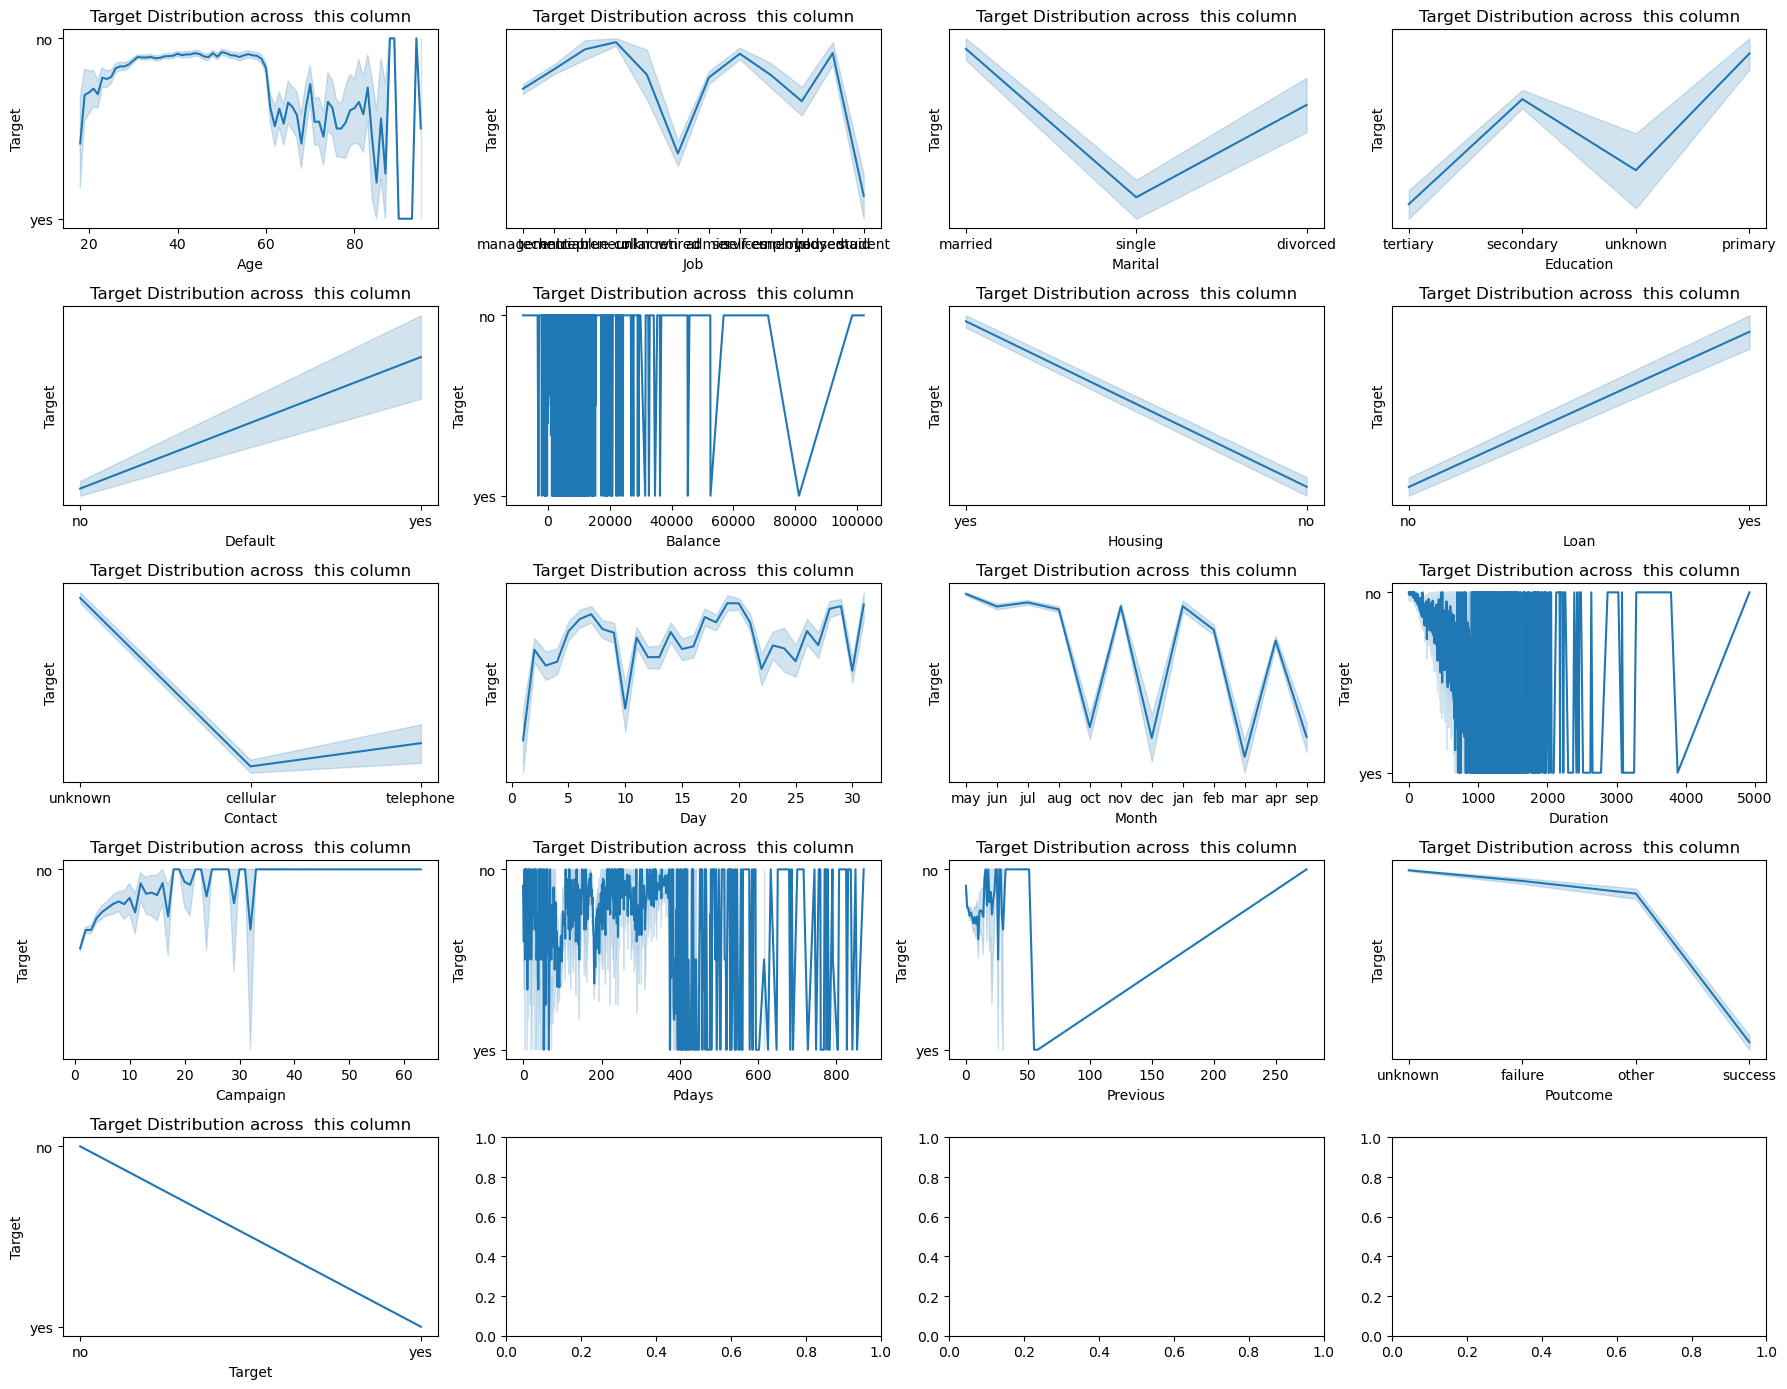

In [17]:
columns = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'Target']
titles = ['Target Distribution across  this column']

fig, axs = plt.subplots(5, 4, figsize=(18, 14))

for i, col in enumerate(columns):
    sns.lineplot(data=df, x=col, y='Target', ax=axs[i//4, i%4])
    axs[i//4, i%4].set_title(titles[0])
    axs[i//4, i%4].set_xlabel(col.capitalize())
    axs[i//4, i%4].set_ylabel('Target')

fig.tight_layout()
plt.show()


# 2-scatterplot
<p>سوف نعرض البيانات بشكل مرئي لكي نفهم توزيع البيانات مع الدخل</p>

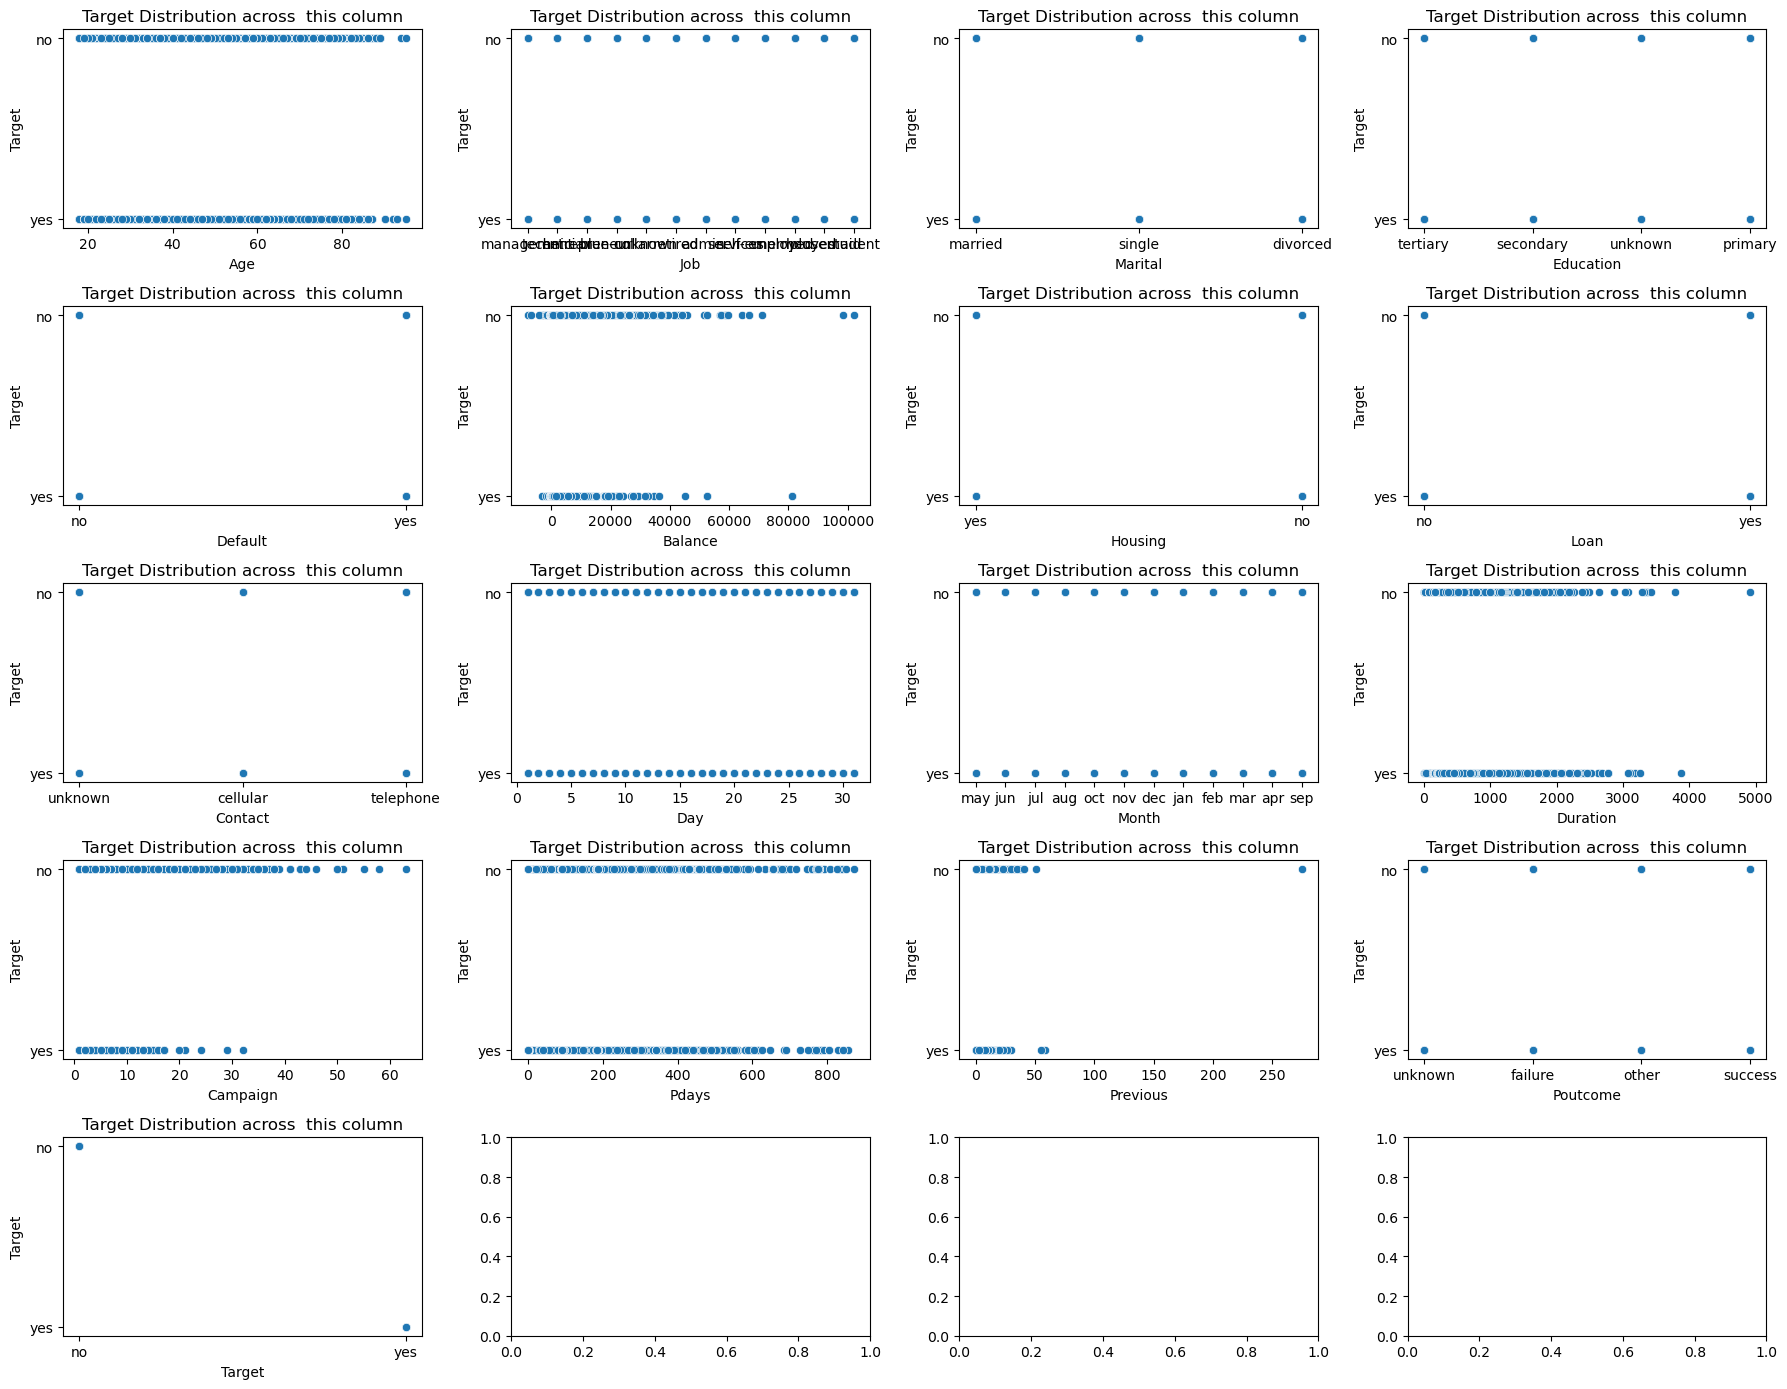

In [19]:
columns = ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'Target']
titles = ['Target Distribution across  this column']

fig, axs = plt.subplots(5, 4, figsize=(18, 14))

for i, col in enumerate(columns):
    sns.scatterplot(data=df, x=col, y='Target', ax=axs[i//4, i%4])
    axs[i//4, i%4].set_title(titles[0])
    axs[i//4, i%4].set_xlabel(col.capitalize())
    axs[i//4, i%4].set_ylabel('Target')

fig.tight_layout()
plt.show()


# 3-barplot
<p>سوف نستخدمه لعرض عدد العينات لكل فئه من الفئه التصنيفيه يهمنا في العامود الغير مستمر.قمنا بوضعه لجميع الاعمده</p>

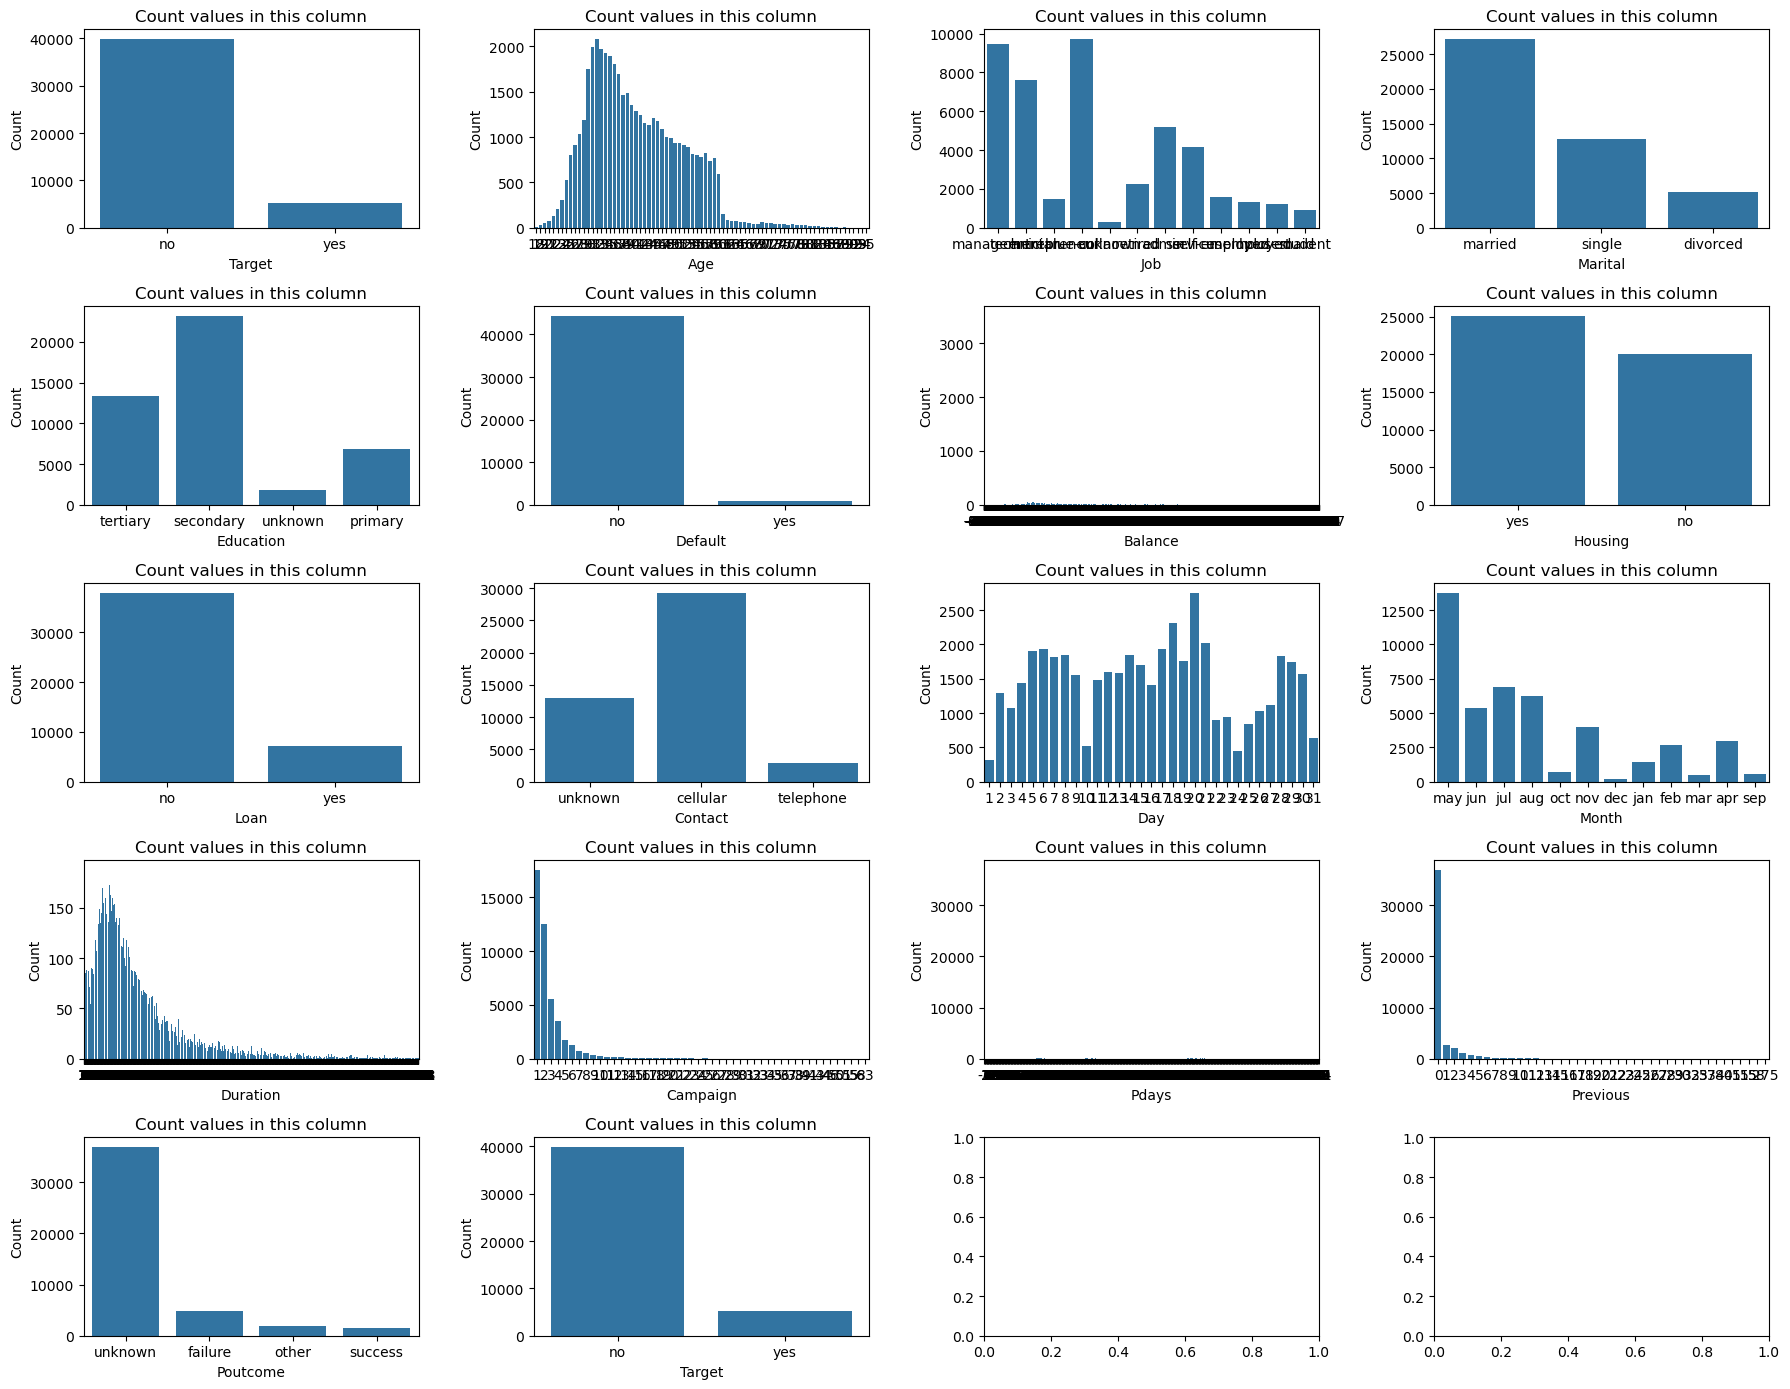

In [21]:
columns = ['Target', 'age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'Target']
titles = ['Count values in this column']

fig, axs = plt.subplots(5, 4, figsize=(18, 14))

for i, col in enumerate(columns):
    sns.countplot(data=df, x=col, ax=axs[i//4, i%4])
    axs[i//4, i%4].set_title(titles[0])
    axs[i//4, i%4].set_xlabel(col.capitalize())
    axs[i//4, i%4].set_ylabel('Count')

fig.tight_layout()
plt.show()


# 4-histogram
 <p>يستخدم لمعرفه توزيع القيم في كل عامود ويمكن استخدامه في القيم المستمره ويمكن استنتاج القيم الشاذه منه</p>

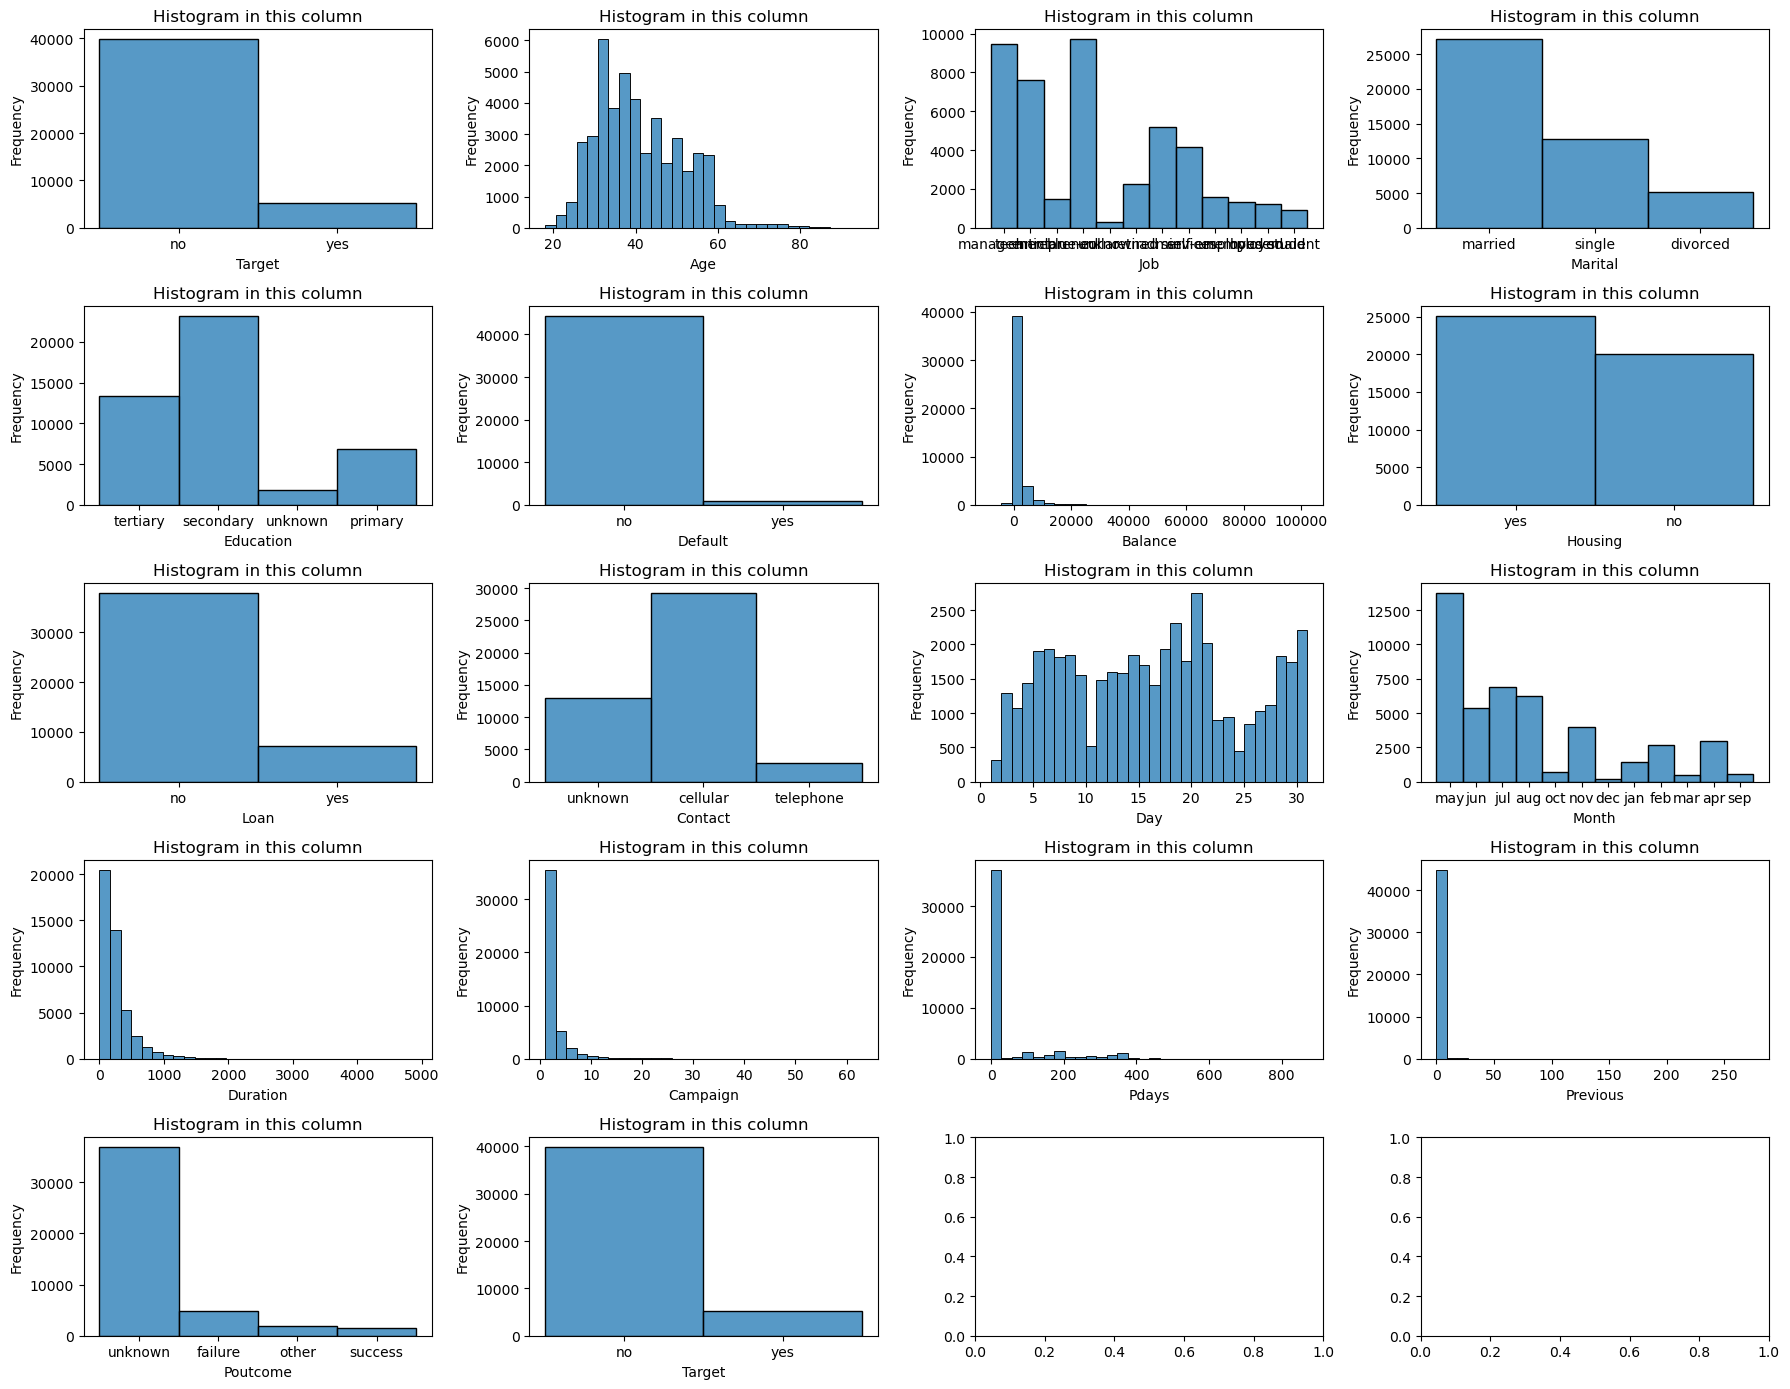

In [23]:
columns = ['Target', 'age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'Target']
titles = ['Histogram in this column']

fig, axs = plt.subplots(5, 4, figsize=(18, 14))

for i, col in enumerate(columns):
    sns.histplot(data=df, x=col, ax=axs[i//4, i%4], bins=30)
    axs[i//4, i%4].set_title(titles[0])
    axs[i//4, i%4].set_xlabel(col.capitalize())
    axs[i//4, i%4].set_ylabel('Frequency')

fig.tight_layout()
plt.show()


# 5-boxplot
<p>يستخدم لتحديد القيم الشاذه</p>

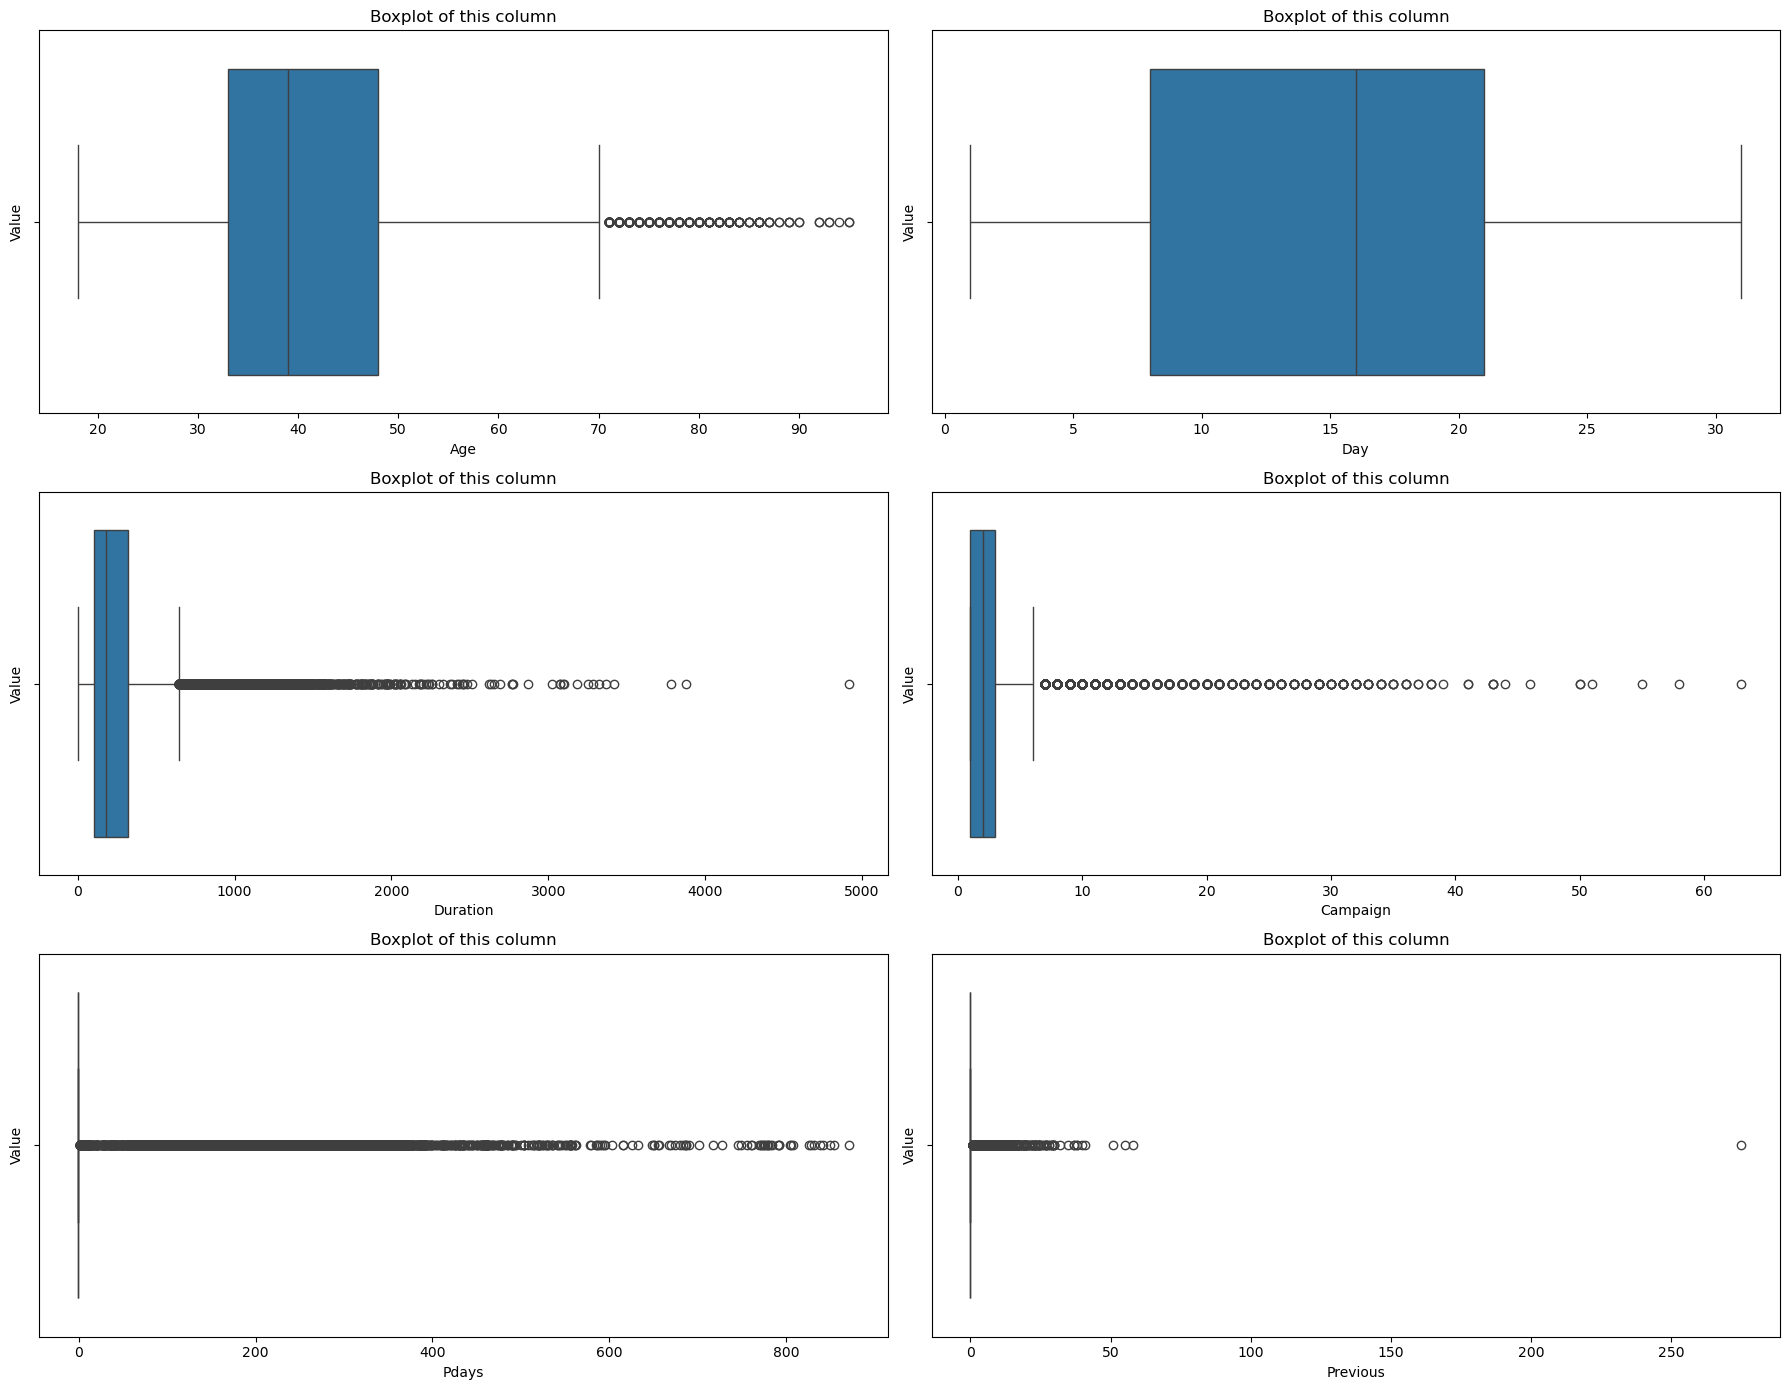

In [25]:
columns = ['age', 'day',  'duration', 'campaign', 'pdays', 'previous']
titles = ['Boxplot of this column']

fig, axs = plt.subplots(3, 2, figsize=(18, 14))

for i, col in enumerate(columns):
    sns.boxplot(data=df, x=col, ax=axs[i//2, i%2])
    axs[i//2, i%2].set_title(titles[0])
    axs[i//2, i%2].set_xlabel(col.capitalize())
    axs[i//2, i%2].set_ylabel('Value')

fig.tight_layout()
plt.show()


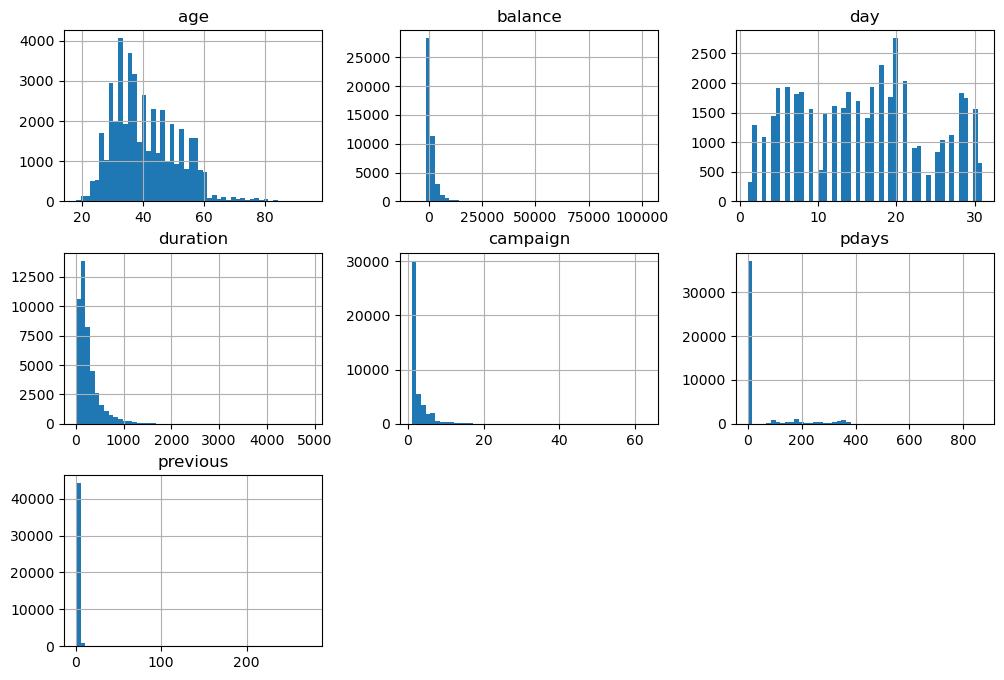

In [26]:
df.hist(bins=50, figsize=(12,8))
plt.show()

# Handle missing values
<p>التحقق من وجود القيم المفقوده</p>

<BarContainer object of 17 artists>

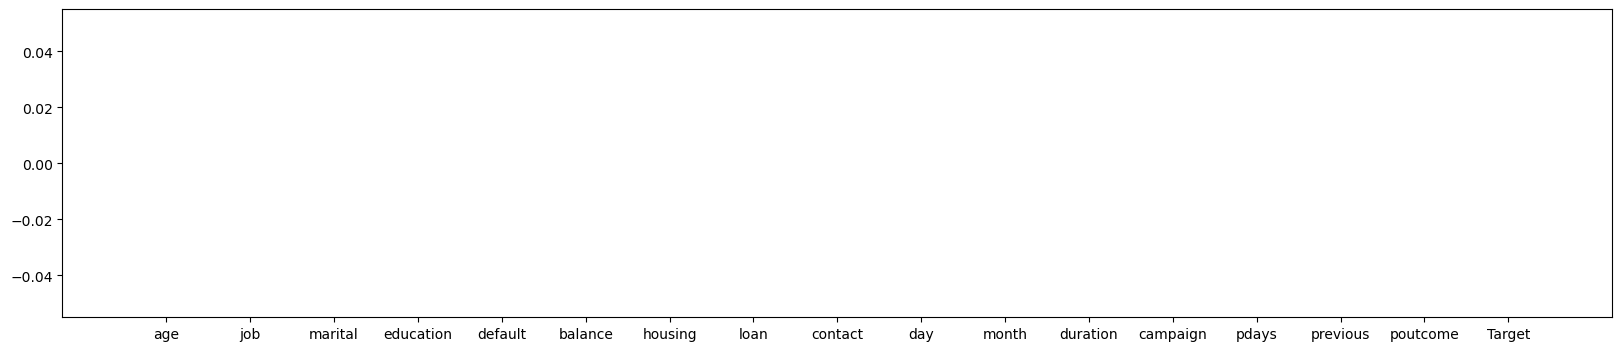

In [28]:
plt.figure(figsize=(20, 4))
plt.bar(df.columns, df.isnull().sum())

In [29]:
#We note that there are no missing values.
#If there are any, the numbers will be processed using the arithmetic mean,
#df1 = df2.fillna(df.columns.mean()) 
#and the texts using the most repeated value.

# Outliers processing
<p>The IsolationForest algorithm gave better results than determining (Lower Bound and Upper Bound).</p>

In [31]:
# calculate summary statistics 
columns_to_plot = ['age', 'day',  'duration', 'campaign', 'pdays', 'previous']
d=df.select_dtypes(include=[np.number])
df1 = pd.DataFrame()
for column in columns_to_plot:
    mean = d[column].mean() 
    std = d[column].std() 
    
    # Calculate the lower and upper bounds 
    lower_bound = mean - std * 2
    upper_bound = mean + std * 2
    
    print('Lower Bound for', column, ':', lower_bound) 
    print('Upper Bound for', column, ':', upper_bound) 
    print("-------------")
    # Drop the outliers
    df1[column] = d[(d[column] >= lower_bound) & (d[column] <= upper_bound)][column]
#  nanعند حصر المجال بهذه الطريقه وحذف القيم خارج هذا المجال سيؤدي الي وجود قيم 
#  IsolationForest على عكس 

Lower Bound for age : 19.698686132377507
Upper Bound for age : 62.173734296279235
-------------
Lower Bound for day : -0.8385335142014405
Upper Bound for day : 32.4513710979753
-------------
Lower Bound for duration : -256.8925447488728
Upper Bound for duration : 773.218704311811
-------------
Lower Bound for campaign : -3.432201108313554
Upper Bound for campaign : 8.959882424807327
-------------
Lower Bound for pdays : -160.0596640189878
Upper Bound for pdays : 240.455319943431
-------------
Lower Bound for previous : -4.026558717232292
Upper Bound for previous : 5.187205462493401
-------------


<p>التحقق من القيم المفقوده ومعالجتها باستراتيجيه الوسيط</p>

<BarContainer object of 6 artists>

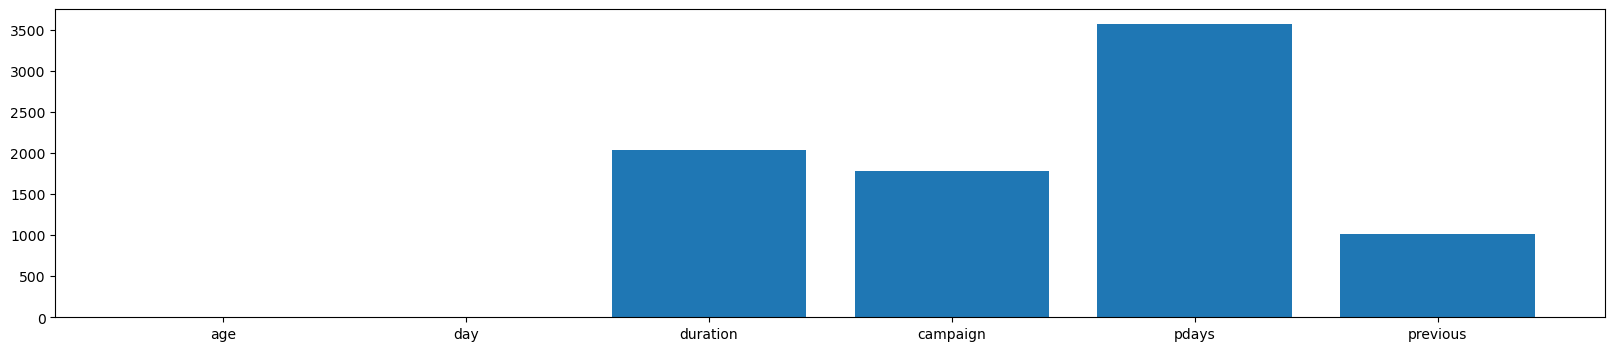

In [33]:
plt.figure(figsize=(20, 4))
plt.bar(df1.columns, df1.isnull().sum())

In [34]:
#Handle missing values
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="median")
imputer.fit(df1)
df1=imputer.transform(df1)
print('missing value:',df1.isnull().any(axis=1).sum())

missing value: 0


<p>التحقق من معالجه القيم الشاذه باستخدام الرسم والمخططات</p>

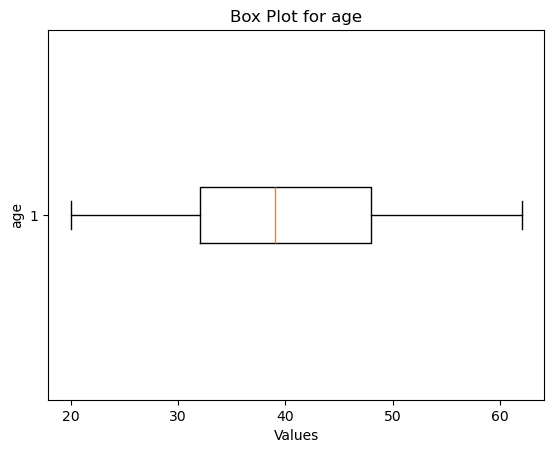

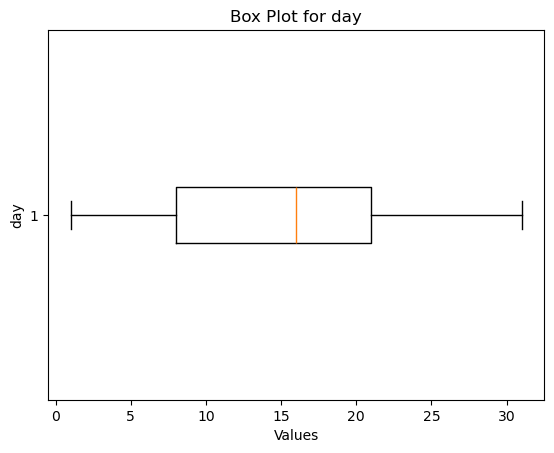

In [36]:
columns_to_plot = ['age', 'day']
for column in columns_to_plot:
    plt.figure()
    plt.boxplot(df1[column], vert=False)
    plt.ylabel(column)
    plt.xlabel('Values')
    plt.title(f'Box Plot for {column}')
    plt.show()

In [37]:
df1.columns

Index(['age', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

# Data Encoding 

In [39]:
df.describe(include=[object])

,job,marital,education,default,housing,loan,contact,month,poutcome,Target
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


<p>يستخدم الترميز بحيث يثوم بترقيم الكلاسات كم 1 يقضب اسنخدامه اذا كان عدد الكلاسات 5 او اقل</p>

In [41]:
#using label encoder for columns:  Target  --->just 2 values
from sklearn.preprocessing import LabelEncoder  
encoder = LabelEncoder()
d2 = pd.DataFrame()
#for col in columns_to_encode:
d2['Target'+'_enc'] = encoder.fit_transform(df['Target'])
df.drop('Target', axis=1, inplace=True)


# Applay Heatmap
<p>يستخدم لمعرف العلاقه بين عامود الهدف والاعمده الرقميه الاخرى بحيث العامود الذي ليس له علاقه مع عامود الهدف يحذف</p>

In [43]:
#Merge number columns with text columns after encoding
d3=pd.merge(d2, df1, left_index=True, right_index=True)

In [44]:
d3.columns

Index(['Target_enc', 'age', 'day', 'duration', 'campaign', 'pdays',
       'previous'],
      dtype='object')

<function matplotlib.pyplot.show(close=None, block=None)>

<Figure size 1400x1000 with 0 Axes>

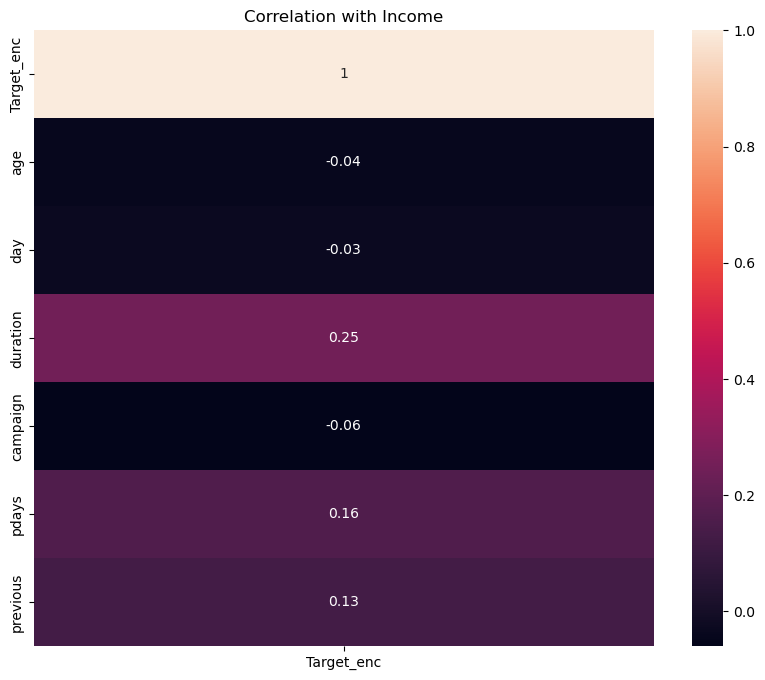

In [45]:
plt.figure(figsize=(14, 10))
correlation_matrix = d3.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix[['Target_enc']].round(2), annot=True, fmt='g')
plt.title('Correlation with Income')
plt.show

In [46]:
#We notice from the histogram that the capital loss column has all zero values,
# Salary was removed as there is no relationship between it and income
#so we will delete it because it is not important.
df1.drop(columns=['day','age', 'campaign'], inplace=True) 
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome'],
      dtype='object')

<p>يستخدم الترميز الثنائي اذا كانت الكلاسات اكبر من 5 يفذل استخدامه بحيث يضع كل كلاس بعامود مع قيم 1 و 0</p>

In [48]:
#using OneHot Encoder for columns: State-gov,
#Occupation, Relationship, Race, Gender, Native Country--->more than 5 values
from sklearn.preprocessing import OneHotEncoder
d0=df.select_dtypes(include=[object])
onehot_encoder = OneHotEncoder(sparse_output=False)

onehot_encoder = onehot_encoder.fit(d0)

d3 = onehot_encoder.transform(d0)


In [49]:
#Merge text columns after encoding
df2=pd.merge(d2, d3, left_index=True, right_index=True)

In [50]:
df2.columns

Index(['Target_enc', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'education_primary', 'education_secondary', 'education_tertiary',
       'education_unknown', 'default_no', 'default_yes', 'housing_no',
       'housing_yes', 'loan_no', 'loan_yes', 'contact_cellular',
       'contact_telephone', 'contact_unknown', 'month_apr', 'month_aug',
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'poutcome_unknown'],
      dtype='object')

In [51]:
#Merge number columns with text columns after encoding
df3=pd.merge(df2, df1, left_index=True, right_index=True)

In [52]:
df3.columns

Index(['Target_enc', 'job_admin.', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_divorced', 'marital_married', 'marital_single',
       'education_primary', 'education_secondary', 'education_tertiary',
       'education_unknown', 'default_no', 'default_yes', 'housing_no',
       'housing_yes', 'loan_no', 'loan_yes', 'contact_cellular',
       'contact_telephone', 'contact_unknown', 'month_apr', 'month_aug',
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'poutcome_unknown', 'duration', 'pdays', 'previous'],
      dtype='object')

In [53]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44203 entries, 0 to 45210
Data columns (total 48 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Target_enc           44203 non-null  int32  
 1   job_admin.           44203 non-null  float64
 2   job_blue-collar      44203 non-null  float64
 3   job_entrepreneur     44203 non-null  float64
 4   job_housemaid        44203 non-null  float64
 5   job_management       44203 non-null  float64
 6   job_retired          44203 non-null  float64
 7   job_self-employed    44203 non-null  float64
 8   job_services         44203 non-null  float64
 9   job_student          44203 non-null  float64
 10  job_technician       44203 non-null  float64
 11  job_unemployed       44203 non-null  float64
 12  job_unknown          44203 non-null  float64
 13  marital_divorced     44203 non-null  float64
 14  marital_married      44203 non-null  float64
 15  marital_single       44203 non-null  floa

In [54]:
df3.describe()

,Target_enc,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,duration,pdays,previous
count,44203.000000,44203.000000,44203.00000,44203.000000,44203.000000,44203.000000,44203.000000,44203.000000,44203.000000,44203.000000,...,44203.000000,44203.000000,44203.000000,44203.000000,44203.000000,44203.000000,44203.000000,44203.000000,44203.000000,44203.000000
mean,0.110060,0.116644,0.21994,0.033391,0.027147,0.212655,0.033753,0.035473,0.093953,0.020157,...,0.088229,0.013868,0.010723,0.107730,0.040178,0.030564,0.821528,213.411714,12.740221,0.336267
std,0.312969,0.320999,0.41421,0.179658,0.162515,0.409190,0.180596,0.184973,0.291766,0.140539,...,0.283631,0.116944,0.102998,0.310043,0.196379,0.172134,0.382914,156.651529,44.907134,0.919522
min,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000
25%,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,102.000000,-1.000000,0.000000
50%,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,171.000000,-1.000000,0.000000
75%,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,280.000000,-1.000000,0.000000
max,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,773.000000,240.000000,5.000000


In [55]:
print(df3["Target_enc"].value_counts())

Target_enc
0    39338
1     4865
Name: count, dtype: int64


<p>فحص العلاقه بين عامود الهدف مع جميع العواميد</p>

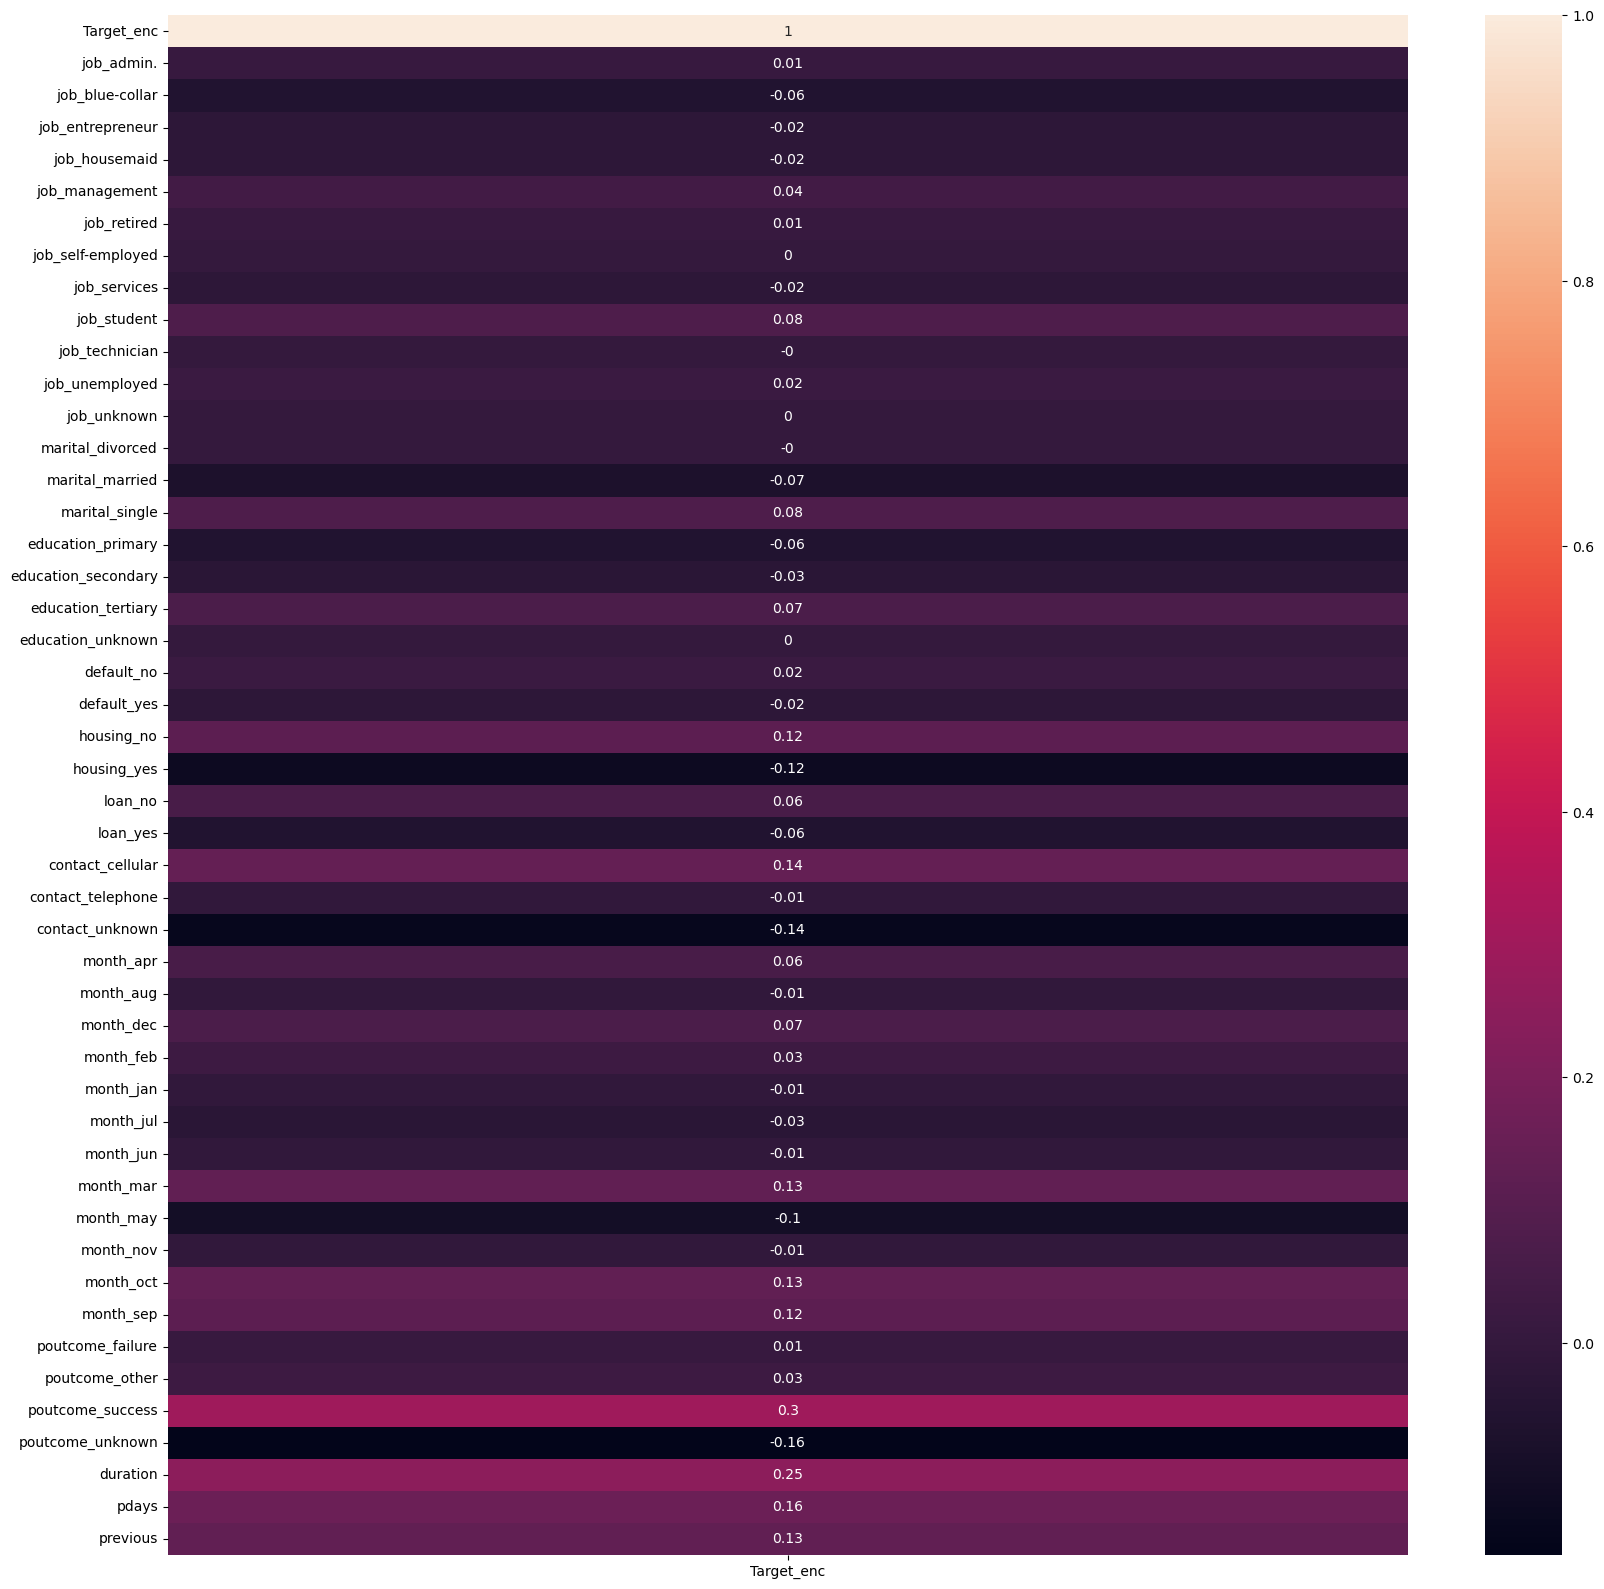

In [57]:
plt.figure(figsize=(20, 20))
correlation_matrix = df3.corr()
sns.heatmap(correlation_matrix[['Target_enc']].round(2), annot=True, fmt='g')
plt.show()


In [58]:
from sklearn.preprocessing import MinMaxScaler 
  
df4 = pd.DataFrame()
scaler = MinMaxScaler()
scaled_array = scaler.fit_transform(df3)
df4 = pd.DataFrame(scaled_array, columns=df3.columns)
df4.head()

,Target_enc,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,duration,pdays,previous
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.337646,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.195343,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.098318,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.119017,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.256145,0.0,0.0


# Dataset split

In [60]:
from sklearn.model_selection import train_test_split
X = df4.loc[:, df4.columns != 'Target_enc']
Y = df4['Target_enc']
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state=42)

# Supervised:

# 1-Applay Decision Tree Classifier:

<h3>3- Finding the optimal parameters of the decision tree </h3>

<h3> Pre-pruning technique </h3>

In [64]:
from sklearn.model_selection import GridSearchCV

tree_params = [{'max_depth': list(range(1, 15)), 'criterion': ['entropy', 'gini'] }]

clf = DecisionTreeClassifier()

model = GridSearchCV(clf, tree_params, cv = 10, scoring='accuracy')

model.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid=[{'criterion': ['entropy', 'gini'],
                          'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                        13, 14]}],
             scoring='accuracy')

<P> هنا نقوم باختيار افضل معيار وافضل عمق لكي لا يظهر لدينا الافراط في التعلم وهو مطابقه بيانات التدريب بدقه عاليه لكن الاختبار لا</P>

In [66]:
model.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=9)

#  Draw Tree

[Text(0.4807655775075988, 0.95, 'x[44] <= 0.219\nentropy = 0.498\nsamples = 30942\nvalue = [27554, 3388]'),
 Text(0.22720364741641338, 0.85, 'x[42] <= 0.5\nentropy = 0.172\nsamples = 14723\nvalue = [14346, 377]'),
 Text(0.15577507598784193, 0.75, 'x[35] <= 0.5\nentropy = 0.141\nsamples = 14470\nvalue = [14182, 288]'),
 Text(0.09878419452887538, 0.65, 'x[44] <= 0.1\nentropy = 0.125\nsamples = 14353\nvalue = [14106.0, 247.0]'),
 Text(0.04673252279635259, 0.55, 'x[31] <= 0.5\nentropy = 0.031\nsamples = 5034\nvalue = [5018, 16]'),
 Text(0.03267477203647416, 0.45, 'x[28] <= 0.5\nentropy = 0.024\nsamples = 4713\nvalue = [4702, 11]'),
 Text(0.022796352583586626, 0.35, 'x[14] <= 0.5\nentropy = 0.019\nsamples = 4475\nvalue = [4467, 8]'),
 Text(0.0121580547112462, 0.25, 'x[38] <= 0.5\nentropy = 0.011\nsamples = 3267\nvalue = [3264, 3]'),
 Text(0.0060790273556231, 0.15, 'x[26] <= 0.5\nentropy = 0.007\nsamples = 3238\nvalue = [3236, 2]'),
 Text(0.00303951367781155, 0.05, 'entropy = 0.004\nsamples 

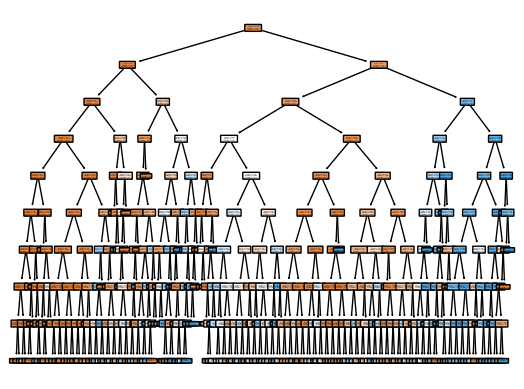

In [68]:
# Implementing the values 
model_optimal = DecisionTreeClassifier(criterion='entropy', max_depth=9, random_state=0)


# fit the model
model_optimal.fit(X_train, y_train)

plot_tree(model_optimal,filled=True,rounded=True)

In [69]:
y_pred_en_op = model_optimal.predict(X_test)

In [70]:
# print the scores on training and test set

print('Training set score: {:.4f}'.format(model_optimal.score(X_train, y_train)))

print('Test set score: {:.4f}'.format(model_optimal.score(X_test, y_test)))

Training set score: 0.9175
Test set score: 0.9025


# Evaluate the model_optimal
<p> Check accuracy score with criterion entropy</p>
<p>We can see that the training-set score and test-set score is same as above. The training-set accuracy score is 0.9175 while the test-set accuracy to be 0.9025 These two values are quite comparable. So, there is no sign of overfitting.</p> 


Accuracy =  0.9026468592112209
[[11486   298]
 [  993   484]]
              precision    recall  f1-score   support

         0.0       0.92      0.97      0.95     11784
         1.0       0.62      0.33      0.43      1477

    accuracy                           0.90     13261
   macro avg       0.77      0.65      0.69     13261
weighted avg       0.89      0.90      0.89     13261



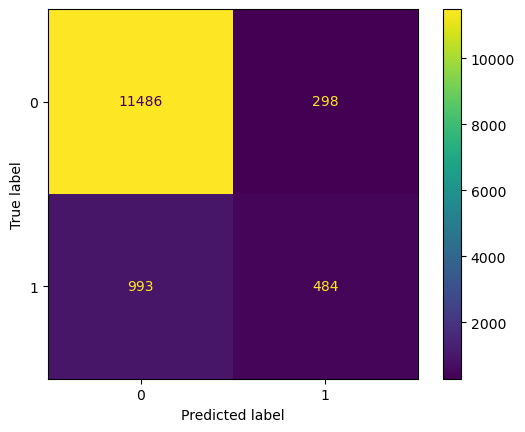

In [72]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import metrics
import matplotlib.pyplot as plt
dt = DecisionTreeClassifier(criterion='entropy', max_depth=9)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, pred_dt)
print('Accuracy = ', accuracy_dt)
print(confusion_matrix(y_test, pred_dt))
print(classification_report(y_test, pred_dt))
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, pred_dt), display_labels=[0, 1])
cm_display.plot()
plt.show()


<P>نلاحظ هنا انه تم التنبا بالكلاس الاول بشكل جيد لكن الكلاس الثاني لم يتنبا بشكل جيد ويرجع السبب لقله العينات في الكلاس الثاني لقد تحيز للكلاس الاول يجب موازنه الكلاسات والبيانات</P>

In [74]:
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_en_op})

In [75]:
print(comparison_df.head(50))

       Actual  Predicted
5756      0.0        0.0
26866     0.0        0.0
30667     0.0        0.0
18876     0.0        0.0
20295     0.0        0.0
28661     1.0        0.0
6708      0.0        0.0
20761     0.0        0.0
7705      0.0        0.0
38158     0.0        0.0
36633     0.0        0.0
6735      0.0        0.0
12650     1.0        0.0
12761     0.0        0.0
19718     0.0        0.0
12839     0.0        0.0
116       0.0        0.0
21564     0.0        0.0
19231     1.0        1.0
10398     0.0        0.0
38204     0.0        0.0
1331      0.0        0.0
32663     0.0        0.0
43123     1.0        0.0
44575     1.0        1.0
6663      0.0        0.0
2585      0.0        0.0
9391      0.0        0.0
25819     0.0        0.0
44667     0.0        0.0
18138     0.0        0.0
21397     1.0        0.0
11348     0.0        0.0
9728      0.0        0.0
3697      0.0        0.0
3916      0.0        0.0
7981      0.0        0.0
15606     0.0        0.0
44006     1.0        0.0


# 2-Applay KNN:

<P>ناخذ سلسله من الارقام ونحسب الخطا لها ومن ثم ناخذ اقل خطا مع قيمه الكي التي ظهرت لدينا</P>

Minimum error: 0.1030088228640374 at K = 14


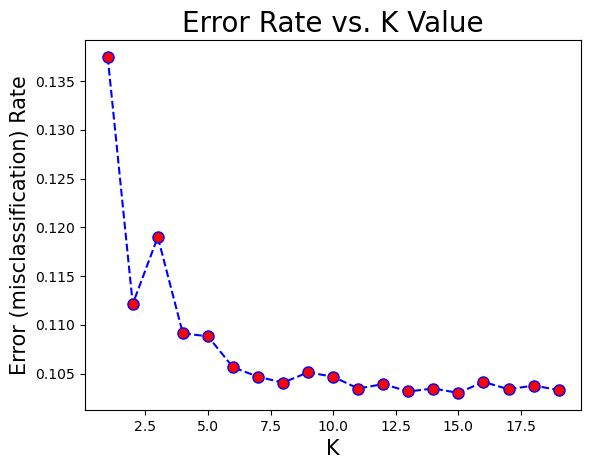

In [78]:
from sklearn.metrics import classification_report,\
    confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
error_rate = []
for i in range(1,20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))
plt.plot(range(1,20),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=8)
plt.title('Error Rate vs. K Value', fontsize=20)
plt.xlabel('K',fontsize=15)
plt.ylabel('Error (misclassification) Rate',fontsize=15)
print("Minimum error:",min(error_rate),"at K =",error_rate.index(min(error_rate)))
K = error_rate.index(min(error_rate))

Accuracy =  0.8965387225699419
[[11658   126]
 [ 1246   231]]
              precision    recall  f1-score   support

         0.0       0.90      0.99      0.94     11784
         1.0       0.65      0.16      0.25      1477

    accuracy                           0.90     13261
   macro avg       0.78      0.57      0.60     13261
weighted avg       0.87      0.90      0.87     13261



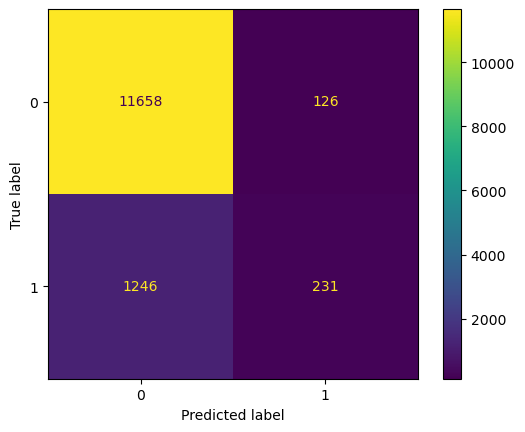

In [79]:
knn3 = KNeighborsClassifier(n_neighbors= K)
knn3.fit(X_train, y_train)
pred3 = knn3.predict(X_test)
from sklearn.metrics import accuracy_score 
accuracy3 = accuracy_score(y_test, pred3)

print('Accuracy = ', accuracy3)
print(confusion_matrix(y_test, pred3))
print(classification_report(y_test, pred3))
from sklearn import metrics
import matplotlib.pyplot as plt

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix(y_test, pred3), display_labels = [0, 1])

cm_display.plot()
plt.show()

<P>نلاحظ هنا انه تم التنبا بالكلاس الاول بشكل جيد لكن الكلاس الثاني لم يتنبا بشكل جيد ويرجع السبب لقله العينات في الكلاس الثاني لقد تحيز للكلاس الاول يجب موازنه الكلاسات والبيانات</P>

# 3-Applay RandomForest:
<P>هو مودل مبني على عده اشجار كل شجره ترى عينه مختلفه من البيانات يام اخذ تصويت الاغلبيه من جميع الشجرات ليحدد النتيجه النهائيه</P>

Random Forest Accuracy =  0.8926928587587664
[[11290   494]
 [  929   548]]
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94     11784
         1.0       0.53      0.37      0.44      1477

    accuracy                           0.89     13261
   macro avg       0.72      0.66      0.69     13261
weighted avg       0.88      0.89      0.88     13261



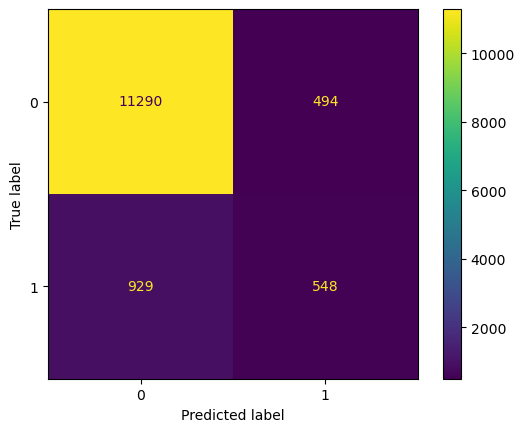

In [82]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import metrics
import matplotlib.pyplot as plt
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, pred_rf)
print('Random Forest Accuracy = ', accuracy_rf)
print(confusion_matrix(y_test, pred_rf))
print(classification_report(y_test, pred_rf))
cm_display_rf = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, pred_rf), display_labels=[0, 1])
cm_display_rf.plot()
plt.show()

<P>نلاحظ هنا انه تم التنبا بالكلاس الاول بشكل جيد لكن الكلاس الثاني لم يتنبا بشكل جيد ويرجع السبب لقله العينات في الكلاس الثاني لقد تحيز للكلاس الاول يجب موازنه الكلاسات والبيانات</P>

# <p>----------------------------------------------------------</p>
# <p>----------------------------------------------------------</p>

# UnSupervised:

# 1-Kmeans
<p>حساب المسافات التربيعيه بين النقاط ومركو الكلاس لعدد مختلف من الكلاسات نطبقه لاختيار العدد الامثل من الكلاسات</p>

In [87]:
from sklearn.cluster import KMeans
inertia = []
range_ = range(1,30)
for i in range_:
    km = KMeans(n_clusters= i).fit(df4)
    inertia.append(km.inertia_)

 <p>نستخدم المخطط لاختيار العدد الامثل من الكلاسات نحن نبحث عن النقطه التي تحدث تغير كبير عندما تنخفض بشكل حاد ثم تبدا تستقر</p>

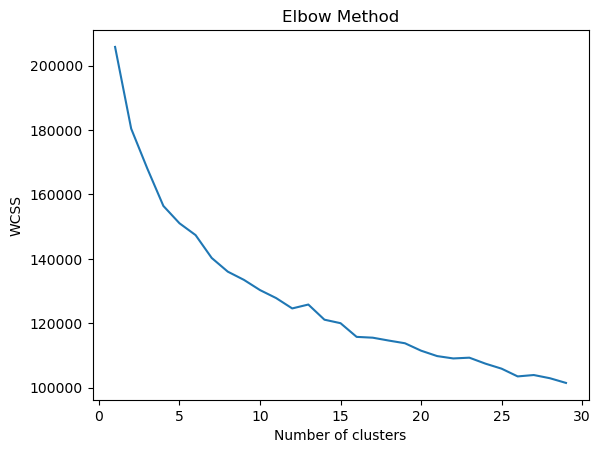

In [89]:
import matplotlib.pyplot as plt
plt.plot(range(1, 30), inertia)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')  # Within cluster sum of squares
plt.show()

<p>نطبق المودل مع افضل قيمه للكلاسات</p>

In [91]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df4)

df4['cluster'] = clusters
print("عدد العينات في كل Cluster:")
print(df4['cluster'].value_counts().sort_index())

عدد العينات في كل Cluster:
cluster
0    15301
1    18991
2     9911
Name: count, dtype: int64


In [92]:
df4.head()

,Target_enc,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,...,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown,duration,pdays,previous,cluster
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.337646,0.0,0.0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.195343,0.0,0.0,2
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.098318,0.0,0.0,0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.119017,0.0,0.0,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.256145,0.0,0.0,1


In [93]:
from sklearn.metrics import silhouette_score
silhouette_score(df4, clusters)

0.17826717402877112

<p>هو مقياس يستخدم لتقييم جوده العناقيد التي تم تشكيلها</p>

In [95]:
from sklearn.metrics import silhouette_score
numeric_cols = df4.select_dtypes(include='number').columns.drop('cluster')
X = df4[numeric_cols]
score = silhouette_score(X, df4['cluster'])
print(f"Silhouette Score: {score:.4f}")


Silhouette Score: 0.0999


# 2-Applay DBSCAN 

In [97]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [98]:
model_DBSCAN = DBSCAN(eps=1.1)
model_DBSCAN.fit(df4)

DBSCAN(eps=1.1)

In [99]:
labels = model_DBSCAN.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"عدد الكلاسترز: {n_clusters}")

عدد الكلاسترز: 1495


In [100]:
from sklearn.metrics import silhouette_score
#0.4944 eps=1.1, min_samples=5
score = silhouette_score(df4, model_DBSCAN.labels_)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.4943
